# Explainability Analysis

This notebook evaluates the explainability of the three trained object detection models used in the project:

- YOLOv8n using detection-specific Grad-CAM
- RT-DETR using detection-specific attention rollout
- DEIMv2 (DINO-based) using query-specific deformable cross-attention

No model training, fine-tuning, or modification of the trained checkpoints is performed.

The notebook uses the existing trained models and the existing explainability implementations.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()

if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

from src.explainability.yolov8_gradcam import YOLOv8GradCAM
from src.explainability.deimv2_attention import DEIMv2Attention

print("Project root:", ROOT)

Project root: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison


In [2]:
IMAGE_DIR = ROOT / "data" / "processed" / "test" / "images"
LABEL_DIR = ROOT / "data" / "processed" / "test" / "labels"

images = []

for image_path in sorted(IMAGE_DIR.iterdir()):
    if image_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        continue

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if label_path.exists() and label_path.read_text(encoding="utf-8").strip():
        images.append((image_path, label_path))

    if len(images) == 3:
        break

print("Selected images:")

for image_path, label_path in images:
    print(image_path)
    print(label_path)

Selected images:
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160136976.jpg
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels\Image_20231128160136976.txt
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160436963.jpg
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels\Image_20231128160436963.txt
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160506980.jpg
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels\Image_20231128160506980.txt


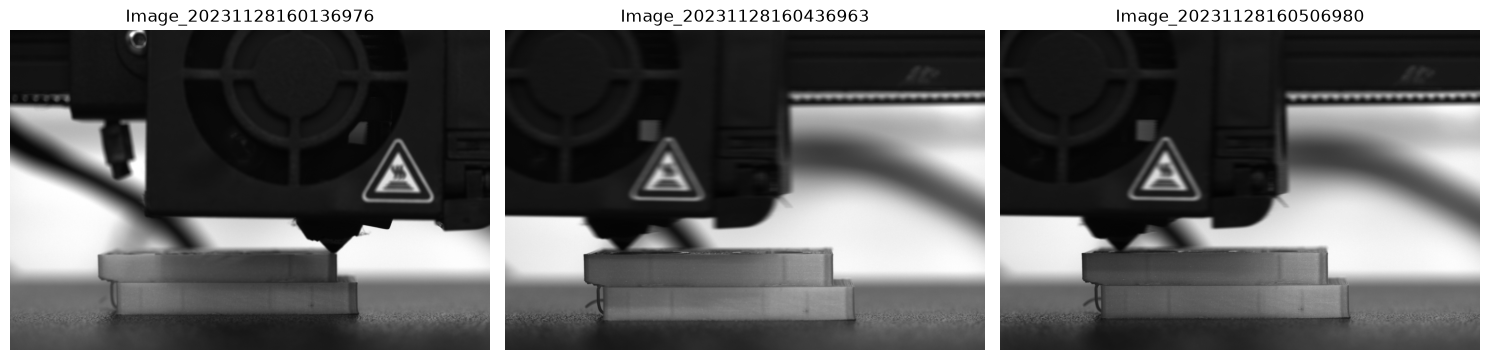

In [3]:
plt.figure(figsize=(15, 5))

for i, (image_path, _) in enumerate(images):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(1, len(images), i + 1)
    ax.imshow(image)
    ax.set_title(image_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
YOLO_WEIGHTS = ROOT / "results" / "baseline_yolov8" / "run" / "weights" / "best.pt"
YOLO_OUTPUT = ROOT / "results" / "explainability" / "yolov8"

YOLO_OUTPUT.mkdir(parents=True, exist_ok=True)

yolo_model = YOLO(str(YOLO_WEIGHTS))

yolo_gradcam = YOLOv8GradCAM(
    model=yolo_model,
    device="cpu",
    conf_threshold=0.25,
    imgsz=640,
)

yolo_results = []

for i, (image_path, _) in enumerate(images, 1):
    output_path = YOLO_OUTPUT / f"{image_path.stem}.jpg"

    print(f"\nYOLOv8 Grad-CAM {i}/{len(images)}")
    print("Image:", image_path)

    try:
        result = yolo_gradcam.generate(
            image_path=str(image_path),
            detection_index=0,
            output_path=str(output_path),
        )

        yolo_results.append({
            "image": image_path,
            "output": output_path,
            "class": result.get("prediction_class_name"),
            "confidence": result.get("prediction_confidence"),
            "iou": result.get("raw_prediction_match_iou"),
        })

        print("Class:", result.get("prediction_class_name"))
        print("Confidence:", result.get("prediction_confidence"))
        print("IoU:", result.get("raw_prediction_match_iou"))
        print("Output:", output_path)

    except Exception as e:
        print("FAILED:", type(e).__name__, e)


YOLOv8 Grad-CAM 1/3
Image: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160136976.jpg
Selected image: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160136976.jpg
Annotation: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels\Image_20231128160136976.txt
Raw anchor: 7496
Class: 1
Confidence: 0.8638
Target layer: Conv(
  (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Saved: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\yolov8\Image_20231128160136976.jpg
Class: Layer_shifting
Confidence: 0.8638086318969727
IoU: None
Output: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-c

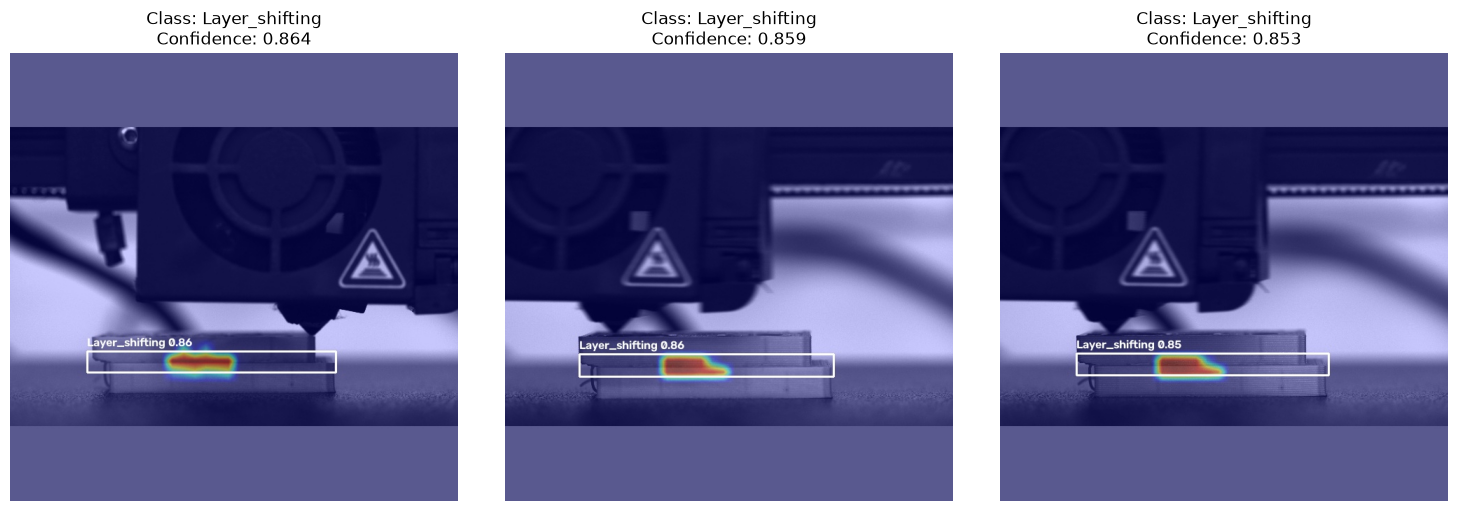

In [5]:
valid_results = [r for r in yolo_results if r["output"].exists()]

plt.figure(figsize=(15, 5))

for i, result in enumerate(valid_results):
    image = cv2.imread(str(result["output"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(1, len(valid_results), i + 1)
    ax.imshow(image)
    ax.set_title(
        f"Class: {result['class']}\n"
        f"Confidence: {result['confidence']:.3f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## RT-DETR Explainability

RT-DETR explainability is generated using the existing
`attention_rollout.py` implementation.

The method is detection-specific and uses the selected decoder query
instead of averaging attention across the entire encoder.

In [6]:
import subprocess

RTDETR_SCRIPT = ROOT / "src" / "explainability" / "attention_rollout.py"

print("Running RT-DETR explainability...")
print("Script:", RTDETR_SCRIPT)

result = subprocess.run(
    [sys.executable, str(RTDETR_SCRIPT)],
    cwd=str(ROOT),
    capture_output=False,
)

print("\nRT-DETR exit code:", result.returncode)

Running RT-DETR explainability...
Script: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\src\explainability\attention_rollout.py

RT-DETR exit code: 0


In [7]:
RTDETR_OUTPUT = ROOT / "results" / "explainability" / "rtdetr"

rtdetr_outputs = sorted(
    [
        p for p in RTDETR_OUTPUT.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
)

print("RT-DETR outputs:")

for path in rtdetr_outputs:
    print(path)

RT-DETR outputs:
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\rtdetr\sample_1_Image_20240118161125156.jpg
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\rtdetr\sample_2_Image_20240118123655162.jpg
C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\rtdetr\sample_3_Image_20240102172550131.jpg


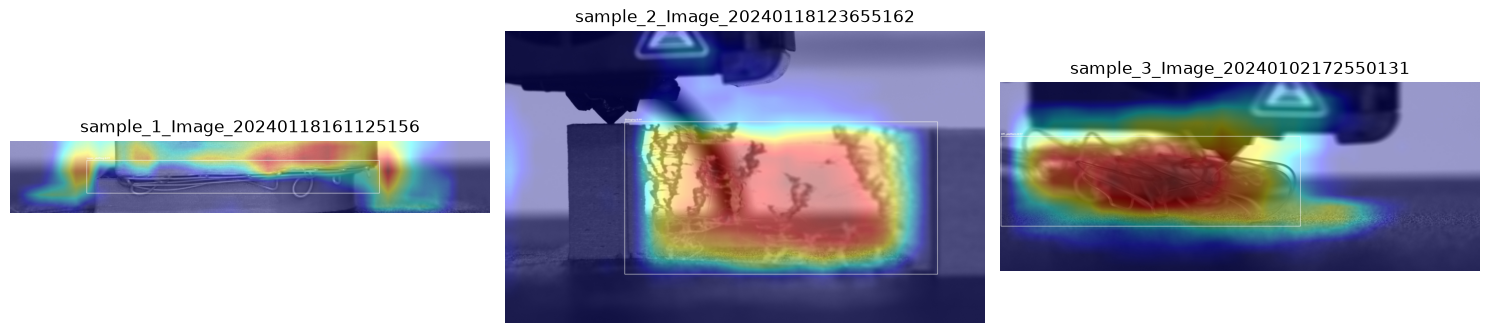

In [8]:
if rtdetr_outputs:
    plt.figure(figsize=(15, 5))

    selected_outputs = rtdetr_outputs[:3]

    for i, path in enumerate(selected_outputs):
        image = cv2.imread(str(path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(1, len(selected_outputs), i + 1)
        ax.imshow(image)
        ax.set_title(path.stem)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No RT-DETR output images found.")

## DEIMv2 Explainability

DEIMv2 (DINO-based) explainability is generated using the existing
`deimv2_attention.py` implementation.

The explanation is detection-specific: the decoder query with the
highest confidence is selected, and its deformable cross-attention
across the multi-scale feature levels is mapped back to the input image.

This approach avoids using a global average attention map and provides
a spatial explanation associated with the selected detection.

No training or fine-tuning is performed. The existing trained DEIMv2
checkpoint is used directly.

In [9]:
DEIM_OUTPUT = ROOT / "results" / "explainability" / "deimv2"
DEIM_OUTPUT.mkdir(parents=True, exist_ok=True)

DEIM_CANDIDATES = [
    ROOT / "results" / "deimv2" / "checkpoint-2688",
    ROOT / "results" / "dino" / "run" / "checkpoint-2688",
    ROOT / "results" / "DEIMv2" / "checkpoint-2688",
]

checkpoint = next(
    (p for p in DEIM_CANDIDATES if p.exists()),
    None,
)

if checkpoint is None:
    raise FileNotFoundError(
        "DEIMv2 checkpoint was not found."
    )

print("DEIMv2 checkpoint:", checkpoint)

deim = DEIMv2Attention(
    checkpoint=str(checkpoint),
    device="cpu",
)

deim_results = []

for i, (image_path, _) in enumerate(images, 1):
    output_path = DEIM_OUTPUT / f"{image_path.stem}.jpg"

    print(f"\nDEIMv2 {i}/{len(images)}")
    print("Image:", image_path)

    try:
        result = deim.generate(
            image_path=str(image_path),
            output_path=str(output_path),
        )

        deim_results.append({
            "image": image_path,
            "output": output_path,
            "query": result["query_index"],
            "class": result["class_name"],
            "confidence": result["confidence"],
        })

        print("Query:", result["query_index"])
        print("Class:", result["class_name"])
        print("Confidence:", result["confidence"])
        print("Output:", output_path)

    except Exception as e:
        print("FAILED:", type(e).__name__, e)

DEIMv2 checkpoint: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\dino\run\checkpoint-2688


Loading weights:   0%|          | 0/619 [00:00<?, ?it/s]


DEIMv2 1/3
Image: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160136976.jpg
Query: 0
Class: Layer_shifting
Confidence: 0.8013973236083984
Output: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\deimv2\Image_20231128160136976.jpg

DEIMv2 2/3
Image: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160436963.jpg
Query: 0
Class: Layer_shifting
Confidence: 0.8607565760612488
Output: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\explainability\deimv2\Image_20231128160436963.jpg

DEIMv2 3/3
Image: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\images\Image_20231128160506980.jpg
Query: 0
Class: Layer_shifting
Confidence: 0.8737426400184631
Output: C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\

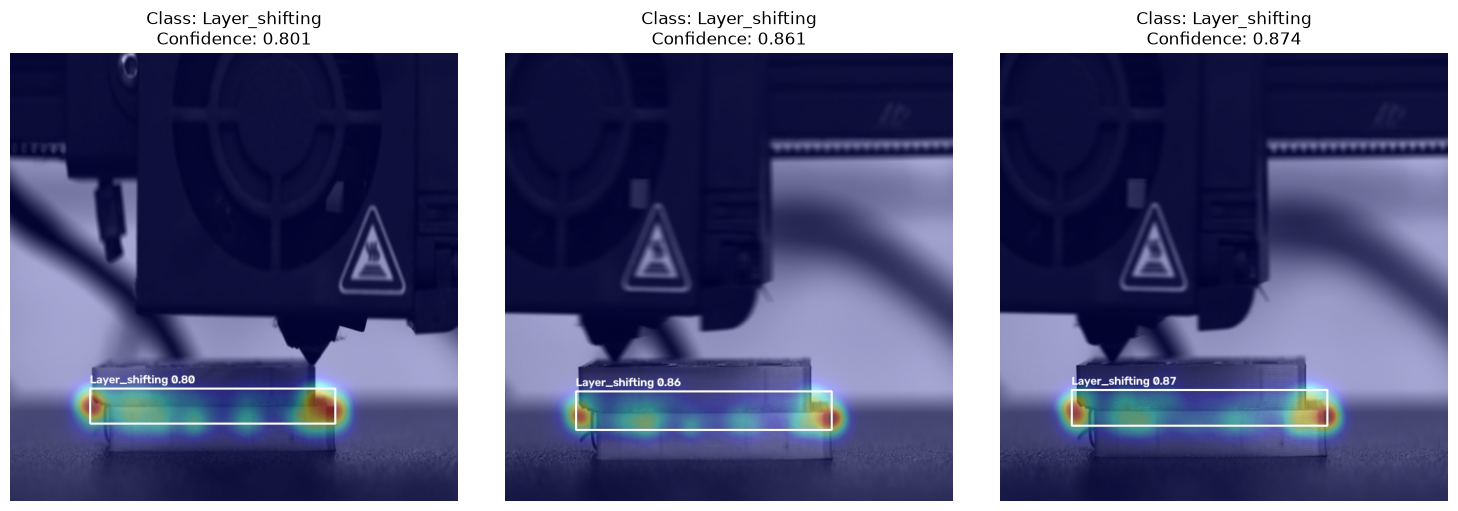

In [10]:
valid_results = [r for r in deim_results if r["output"].exists()]

plt.figure(figsize=(15, 5))

for i, result in enumerate(valid_results):
    image = cv2.imread(str(result["output"]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(1, len(valid_results), i + 1)
    ax.imshow(image)
    ax.set_title(
        f"Class: {result['class']}\n"
        f"Confidence: {result['confidence']:.3f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Final Explainability Comparison

The three explainability methods are compared qualitatively based on the
spatial correspondence between the generated heatmap and the detected
defect region.

### YOLOv8n
Detection-specific Grad-CAM is used to identify the image regions that
contribute to the selected detection.

### RT-DETR
The explanation is generated from the decoder query associated with the
selected detection rather than from a global encoder attention map.

### DEIMv2
The explanation is generated from the deformable cross-attention of the
selected high-confidence decoder query.

No additional training or fine-tuning is performed.

In [12]:
import pandas as pd

summary = []

for result in yolo_results:
    summary.append({
        "Model": "YOLOv8n",
        "Image": result["image"].stem,
        "Class": result["class"],
        "Confidence": result["confidence"],
        "IoU": result["iou"],
    })

for result in deim_results:
    summary.append({
        "Model": "DEIMv2",
        "Image": result["image"].stem,
        "Class": result["class"],
        "Confidence": result["confidence"],
        "IoU": None,
    })

pd.DataFrame(summary)

,Model,Image,Class,Confidence,IoU
0,YOLOv8n,Image_20231128160136976,Layer_shifting,0.863809,None
1,YOLOv8n,Image_20231128160436963,Layer_shifting,0.859413,None
2,YOLOv8n,Image_20231128160506980,Layer_shifting,0.852635,None
3,DEIMv2,Image_20231128160136976,Layer_shifting,0.801397,None
4,DEIMv2,Image_20231128160436963,Layer_shifting,0.860757,None
5,DEIMv2,Image_20231128160506980,Layer_shifting,0.873743,None
